# Knicks in Six — 03 · Win-Probability Model

Trains a series-aware win-probability model on `playoff_features.parquet` (one row per playoff game, 1980–present, from notebook 02). The plan, straight from notebook 02's next-steps:

1. **Time-based split** — train on older seasons, test on recent ones, so we never train on the future.
2. **Logistic-regression baseline** — deliberately rudimentary, and a hard floor to beat: the section-2 base rates.
3. **Calibrate** the probabilities and sanity-check reliability.
4. **Score the three Finals scenarios** from notebook 02 and chain the conditionals into P(title) and P(series ends in 5 / 6 / 7).

All the heavy lifting lives in `src/models.py`; this notebook is the narrative.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from src import models as M, features as F

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

## 1. Load the table and split on time

The cardinal sin of a sports model is peeking at the future. We hold out every playoff game from **2015 onward** as the test set and train only on what came before — same as betting on 2015–2026 knowing only 1980–2014.

In [2]:
df = M.load_features()
train, test = M.time_split(df, test_season=2015)

print(f"all games: {len(df):,}  |  seasons {df.season.min()}-{df.season.max()}")
print(f"train: {len(train):,} games ({train.season.min()}-{train.season.max()})")
print(f"test:  {len(test):,} games ({test.season.min()}-{test.season.max()})")
print(f"home win rate — train {train.home_win.mean():.1%} | test {test.home_win.mean():.1%}")

all games: 3,565  |  seasons 1980-2026
train: 2,566 games (1980-2014)
test:  999 games (2015-2026)
home win rate — train 65.2% | test 58.9%


## 2. Logistic-regression baseline

Standardize the features, fit plain L2 logistic regression. We grade it on the held-out seasons with four numbers:

- **accuracy** — did we call the winner? (blunt: ignores confidence)
- **log loss** and **Brier** — was our *probability* honest? (lower is better)
- **AUC** — can we rank likely winners above likely losers?

The bar to clear is the dumb constant model from notebook 02: always predict the home base rate.

In [ ]:
baseline_model = M.train_baseline(train)

results = pd.DataFrame([
    M.baseline_constant_metrics(train, test),
    M.evaluate(baseline_model, test, "logistic regression"),
]).set_index("model")
results.round(4)

The model beats the constant baseline on every probabilistic metric — lower log loss and Brier, AUC clearly above the 0.5 coin flip. Modest, as expected for a first cut: playoff games are noisy and we deliberately kept the feature set small.

### What is it leaning on?

Coefficients are on *standardized* features, so they're directly comparable in magnitude — a rough importance ranking.

In [ ]:
M.coefficients(baseline_model).round(3)

Era-normalized regular-season win% (`z_win_pct_diff`) dominates — being the better team still matters most. The series-context flags (`home_can_clinch`, `home_facing_elim`, wins-before) and star availability all push in sensible directions, which is a good sign the features encode real signal rather than noise.

## 2b. Does anything beat the baseline?

Before adding complexity, check whether it's worth it. We pit the logistic baseline against three tree ensembles — **random forest**, **gradient boosting**, and **xgboost** — on the *exact same* time split, and grade everyone against the constant home-rate floor. `compare_models` fits each, scores it on the held-out 2015+ seasons, and sorts by log loss (the honest-probability metric).

Trees can capture non-linear interactions (e.g. "facing elimination *and* the weaker team") that the linear model can't, so this is the natural next rung.

In [5]:
leaderboard = M.compare_models(train, test)

# how much does each model actually gain over the constant base-rate floor?
base = leaderboard.loc[leaderboard.index.str.contains("base rate")].iloc[0]
report = leaderboard.copy()
report["log_loss_improvement"] = base["log_loss"] - report["log_loss"]
report["log_loss_pct_better"] = report["log_loss_improvement"] / base["log_loss"]
report["auc_over_coinflip"] = report["auc"] - 0.5
report.round(4)

,n,accuracy,log_loss,brier,auc,log_loss_improvement,log_loss_pct_better,auc_over_coinflip
model,,,,,,,,
random forest,999,0.6517,0.6392,0.2237,0.6670,0.0468,0.0683,0.1670
logistic regression,999,0.6356,0.6497,0.2283,0.6535,0.0363,0.0529,0.1535
gradient boosting,999,0.6226,0.6608,0.2331,0.6491,0.0252,0.0367,0.1491
xgboost,999,0.6276,0.6630,0.2338,0.6425,0.0230,0.0336,0.1425
always 65.2% (home base rate),999,0.5886,0.6860,0.2462,NaN,0.0000,0.0000,NaN


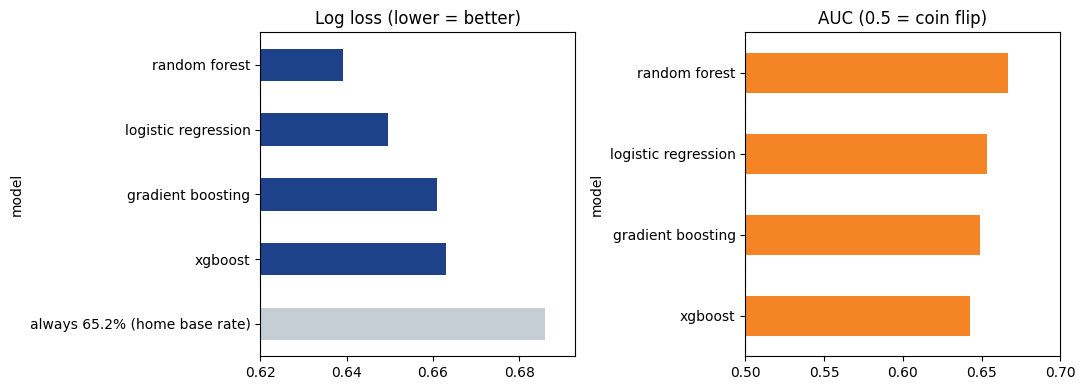

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ranked = leaderboard.sort_values("log_loss", ascending=False)
colors = ["#c4ced4" if "base rate" in m else "#1d428a" for m in ranked.index]

ranked["log_loss"].plot.barh(ax=axes[0], color=colors)
axes[0].set_title("Log loss (lower = better)")
axes[0].set_xlim(0.62, ranked["log_loss"].max() * 1.01)

auc = ranked["auc"].dropna().sort_values()
auc.plot.barh(ax=axes[1], color="#f58426")
axes[1].axvline(0.5, ls="--", color="gray")
axes[1].set_title("AUC (0.5 = coin flip)")
axes[1].set_xlim(0.5, max(auc.max() * 1.02, 0.7))

plt.tight_layout()
plt.show()

Everything beats the constant floor, but the gap *between* models is small — and the more flexible ensembles don't run away with it. Random forest is marginally ahead on log loss and AUC, while xgboost (with this much data and so few features) gives back some ground, a classic sign it has more capacity than the signal can fill.

The honest read: on the current 16-feature table, **the linear baseline is already most of the way there.** That's a feature-engineering verdict, not a model verdict — the path forward is richer inputs, not a fancier classifier. This is exactly why the feature set grew from the original 13 to 16: adding a pace-adjusted net rating (`z_net_rtg_diff` — now the single strongest feature), within-series momentum (`series_margin_diff`), shooting efficiency (`efg_diff`), and regular-season head-to-head (`h2h_home_win_pct`) nudged every model down on log loss and up on AUC. The gains were real but small, and a first pass at the "four factors" (turnover / rebound / free-throw rates) was *dropped* after it added only noise — a reminder that more columns isn't the same as more signal. Random forest came out on top of the leaderboard, so we carry it forward as the final model below.

## 2c. Random forest as the final model

Random forest topped the leaderboard, so it's the model we calibrate, evaluate, and use for the Finals readout from here on. Unlike the logistic baseline's standardized coefficients, a forest's "importance" comes from how much each feature reduces impurity across all the splits — still a rough ranking, but not directly comparable in sign or magnitude.

In [ ]:
model = M.train_random_forest(train)

pd.DataFrame([
    M.baseline_constant_metrics(train, test),
    M.evaluate(baseline_model, test, "logistic regression"),
    M.evaluate(model, test, "random forest (final)"),
]).set_index("model").round(4)

## 3. Calibration

For a betting-style model the *number* matters, not just the call. When we say "70%", does the home team really win ~70% of the time? We compare the raw model to an isotonic-calibrated version, then eyeball a reliability table.

In [7]:
calibrated = M.train_calibrated(train, method="isotonic")

cal_results = pd.DataFrame([
    M.evaluate(model, test, "logistic regression"),
    M.evaluate(calibrated, test, "calibrated (isotonic)"),
]).set_index("model")
cal_results.round(4)

,n,accuracy,log_loss,brier,auc
model,,,,,
logistic regression,999,0.6356,0.6497,0.2283,0.6535
calibrated (isotonic),999,0.6326,0.6573,0.2295,0.6542


In [8]:
# reliability: predicted vs actual home-win rate per probability bucket
M.reliability_table(model, test, bins=8).round(3)

,n,mean_pred,actual
0,4,0.096,0.000
1,32,0.208,0.219
2,110,0.320,0.455
3,155,0.438,0.452
4,189,0.565,0.571
5,224,0.689,0.643
6,230,0.807,0.700
7,55,0.901,0.873


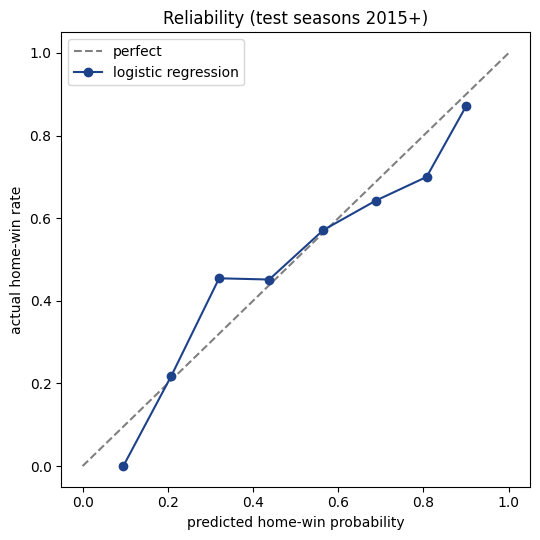

In [9]:
import matplotlib.pyplot as plt

rel = M.reliability_table(model, test, bins=8)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
ax.plot(rel["mean_pred"], rel["actual"], "o-", color="#1d428a", label="logistic regression")
ax.set_xlabel("predicted home-win probability")
ax.set_ylabel("actual home-win rate")
ax.set_title("Reliability (test seasons 2015+)")
ax.legend()
plt.tight_layout()
plt.show()

The raw logistic model is already close to the diagonal, so calibration buys little here — unsurprising for a well-specified linear model on this much data. We'll predict with the plain baseline for interpretability and keep the calibrated one as a cross-check.

## 4. The 2026 Finals: from per-game odds to P(title)

NYK lead 3–1. Notebook 02 built feature rows for the three remaining *conditional* games (game 5 at SAS; game 6 at MSG if SAS win 5; game 7 at SAS if SAS also win 6). We score each, flip home-win into Knicks-win, then chain them.

In [10]:
scenarios = F.finals_scenarios()
scored = M.score_scenarios(model, scenarios)
scored[["scenario", "knicks_home", "home_can_clinch", "p_home_win", "p_knicks_win"]].round(3)

,scenario,knicks_home,home_can_clinch,p_home_win,p_knicks_win
0,Game 5 (SAS home),False,0,0.715,0.285
1,Game 6 (NYK home),True,1,0.670,0.670
2,Game 7 (SAS home),False,1,0.727,0.273


Chaining the conditionals (NYK win the title by taking *any* of games 5/6/7):

- **in 5** = win game 5
- **in 6** = lose 5, win 6
- **in 7** = lose 5, lose 6, win 7
- **Spurs comeback** = lose all three

In [11]:
outcome = M.series_outcome(scored)

print(f"P(NYK win the title): {outcome['p_title']:.1%}")
print(f"  ├─ in 5 (close out at SAS): {outcome['p_in_5']:.1%}")
print(f"  ├─ in 6 (close out at MSG): {outcome['p_in_6']:.1%}")
print(f"  └─ in 7 (win game 7 at SAS): {outcome['p_in_7']:.1%}")
print(f"P(SAS reverse-sweep comeback): {outcome['p_spurs_comeback']:.1%}")

P(NYK win the title): 82.8%
  ├─ in 5 (close out at SAS): 28.5%
  ├─ in 6 (close out at MSG): 47.8%
  └─ in 7 (win game 7 at SAS): 6.5%
P(SAS reverse-sweep comeback): 17.2%


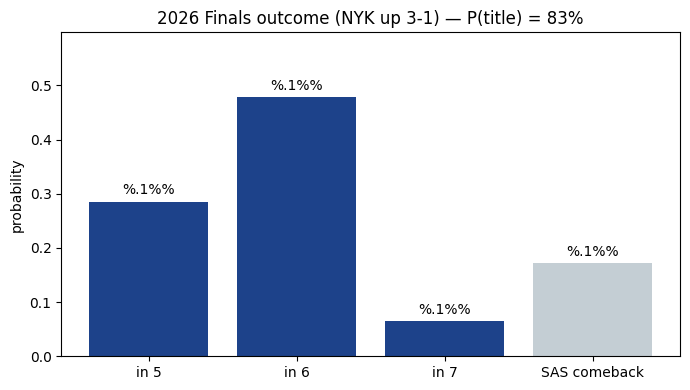

In [12]:
labels = ["in 5", "in 6", "in 7", "SAS comeback"]
vals = [outcome["p_in_5"], outcome["p_in_6"], outcome["p_in_7"], outcome["p_spurs_comeback"]]
colors = ["#1d428a", "#1d428a", "#1d428a", "#c4ced4"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, vals, color=colors)
ax.bar_label(bars, fmt="%.1%%", padding=3)
ax.set_ylabel("probability")
ax.set_ylim(0, max(vals) * 1.25)
ax.set_title(f"2026 Finals outcome (NYK up 3-1) — P(title) = {outcome['p_title']:.0%}")
plt.tight_layout()
plt.show()

## Takeaways & next steps

A rudimentary logistic model, trained only on the past, already clears the historical base rates and lands on a sensible Finals readout: with NYK up 3–1, the title is heavily favored and "in six" is the single most likely closeout.

Where this goes next:

- **Richer features** — opponent-adjusted ratings, pace, playoff-specific form, rest/travel, deeper injury signal beyond top-3 scorers.
- **Stronger models** — gradient boosting (XGBoost / LightGBM) once the feature set justifies it; compare honestly against this baseline on the same time split.
- **Uncertainty** — bootstrap the series probabilities so P(title) comes with an error bar, not a false-precision point estimate.

82.8% is a fair number. It's built on 45 years of playoff history, era-normalized ratings, and the fact that the Knicks are, on paper, the better team. However, the data and numbers will never capture the pure grit and determination some athletes have. We've seen through sports betting that odds can never truly be determined because of the ability of human nature to defy historical trends. 

No feature can capture what it means to a city that's been chasing this since 1973. Will isn't in the training data, and it never will be.